# Comparing historic endpoints and transformed resources
**Author**:  Sian Teesdale

**Date created**: April 2026

**Dataset Scope**: article-4-direction, listed-building-outline, tree, tree-preservation-zone
  
**Purpose**: Data on the Planning platform has been pruned/filtered by the time it is published on the platform. Therefore, we should not be comparing frontend data (Planning platform) with backend data (reporting_historic_endpoint and transformed resources). Therefore, this notebook looks at just the backend data. It also corrects some mistakes in my previous notebook (swapping _size=max for _stream=on, removing duplicate resources, etc).

In [2]:
import pandas as pd
import json
import urllib.request
import matplotlib.pyplot as plt

## Process the reporting historic endpoint/dataset resource

In [3]:
datasets = ['article-4-direction-area', 'tree', 'tree-preservation-zone', 'listed-building-outline']

In [69]:
all_rows = []
last_rowid = 0

while True:
    if last_rowid == 0:
        # First batch: no filter
        url = "https://datasette.planning.data.gov.uk/performance/reporting_historic_endpoints.json?_shape=array&_size=max"
    else:
        # Subsequent batches: filter by rowid__gt
        url = f"https://datasette.planning.data.gov.uk/performance/reporting_historic_endpoints.json?_shape=array&_size=max&rowid__gt={last_rowid}"
    
    response = urllib.request.urlopen(url, timeout=120)
    rows = json.load(response)
    
    if not rows:
        break
    
    all_rows.extend(rows)
    last_rowid = rows[-1]['rowid']
    print(f"Fetched {len(all_rows)} rows...")
    
    if len(rows) < 1000:
        break

report_he = pd.DataFrame(all_rows)
print(f"Total: {len(report_he)} rows")


Fetched 1000 rows...
Fetched 2000 rows...
Fetched 3000 rows...
Fetched 4000 rows...
Fetched 5000 rows...
Fetched 6000 rows...
Fetched 7000 rows...
Fetched 8000 rows...
Fetched 9000 rows...
Fetched 10000 rows...
Fetched 11000 rows...
Fetched 12000 rows...
Fetched 13000 rows...
Fetched 14000 rows...
Fetched 15000 rows...
Fetched 16000 rows...
Fetched 17000 rows...
Fetched 18000 rows...
Fetched 19000 rows...
Fetched 20000 rows...
Fetched 21000 rows...
Fetched 22000 rows...
Fetched 23000 rows...
Fetched 24000 rows...
Fetched 25000 rows...
Fetched 26000 rows...
Fetched 26724 rows...
Total: 26724 rows


In [70]:
# Remove inactive endpoints and filter for only the 4 datasets we're interested in
report_he = report_he.loc[(report_he['dataset'].isin(datasets)) & (report_he['resource_end_date'] == '')]

# WARNING: merging `report_he` directly to `data_resource` can inflate counts
# if `report_he` contains multiple rows for the same resource. In that case
# the same dataset_resource.entity_count is repeated and then summed more than once.
#
# To avoid that, reduce `report_he` to one row per resource before the merge.
report_he = report_he.drop_duplicates(subset=['resource']).copy()

In [71]:
report_he.loc[(report_he['dataset'] == 'article-4-direction-area') & (report_he['name'] == 'London Borough of Barking and Dagenham')]['resource'].item()

'e3eb3651fdb452b7396dbf901df1f54324971d25b71355e6a5f13309a69dfc81'

In [81]:
# Loop over and get the dataset_resource for each dataset, then concatenate into a single dataframe
dfs = []
for data in datasets:
    df = pd.read_csv(f'https://datasette.planning.data.gov.uk/{data}/dataset_resource.csv?_stream=on')
    dfs.append(df)

data_resource = pd.concat(dfs)

In [112]:
dataset_resource_entity_count = pd.merge(report_he, data_resource[['resource', 'dataset', 'entity_count', 'entry_count']], on=['resource', 'dataset'])

# Groupby to get entity-count per LPA
dataset_resource_entity_count_groupby = dataset_resource_entity_count.groupby(['dataset', 'name', 'organisation'])['entity_count'].sum().to_frame('dataset_resource_count').reset_index()

In [113]:
dataset_resource_entity_count.loc[(dataset_resource_entity_count['dataset'] == 'article-4-direction-area') & (dataset_resource_entity_count['name'] == 'London Borough of Camden')]

,rowid,organisation,name,organisation_name,dataset,collection,pipeline,endpoint,endpoint_url,documentation_url,...,latest_status,latest_exception,resource,latest_log_entry_date,endpoint_entry_date,endpoint_end_date,resource_start_date,resource_end_date,entity_count,entry_count
48,12429,local-authority:CMD,London Borough of Camden,London Borough of Camden,article-4-direction-area,article-4-direction,article-4-direction-area,3bbf7138bc9dacbf42700c5d114ba0c1856ae4cdc7c923...,https://opendata.camden.gov.uk/api/views/45mg-...,https://dev.socrata.com/foundry/opendata.camde...,...,200,,9c2020bee401c417e58dfbc605a1a3afb13015fa237e4a...,2026-04-24,2023-08-11,,2026-03-16,,20.0,19


---

# Process the transformed resources

In [91]:
transformed = []
        
for idx, rows in report_he.iterrows():
    organisation = rows['organisation']
    name = rows['name']
    collection = rows['collection']
    dataset = rows['dataset']
    resource = rows['resource']
    
    url = f"http://files.planning.data.gov.uk/{collection}-collection/transformed/{dataset}/{resource}.csv"

    try:
        df = pd.read_csv(url)
    except Exception as e:
        print(f"Failed to fetch {resource}: {e}")
        continue

    entity = df['entity'].astype('string').str.strip()
    entity = entity.mask(entity == '', pd.NA)
    unique_entities = entity.nunique(dropna=True)

    transformed.append({
        'organisation': organisation,
        'name': name,
        'collection': collection,
        'dataset': dataset,
        'resource': resource,
        'unique_entities': unique_entities
    })
    #print(f"Resource: {resource}, Unique Entities: {unique_entities}")

In [92]:
# Convert to dataframe
transformed_resources = pd.DataFrame(transformed)

# Groupby to get entity-count per LPA
transformed_resources_groupby = transformed_resources.groupby(['dataset', 'name', 'organisation'])['unique_entities'].sum().to_frame('transformed_resources_count').reset_index()#.unstack(fill_value=0)

# Merge together

In [114]:
# Merge together the record-level data
cols = ['organisation', 'name', 'dataset', 'collection', 'resource']
individual_resource_summary = pd.merge(dataset_resource_entity_count[cols + ['entity_count']], transformed_resources, on=cols, how='outer')
individual_resource_summary.rename(columns={'entity_count': 'dataset_resource_count',
                                            'unique_entities':'transformed_resources_count'}, inplace=True)

# Check if the entity counts are matching
individual_resource_summary['match'] = individual_resource_summary.apply(lambda row: 'match' if row['transformed_resources_count'] == row['dataset_resource_count'] else 'mismatch', axis=1)

In [115]:
# Merge together the LPA-level data
lpa_summary = pd.merge(dataset_resource_entity_count_groupby, transformed_resources_groupby, on=['dataset', 'name', 'organisation'], how='outer')

# Check if the entity counts are matching
lpa_summary['match'] = lpa_summary.apply(lambda row: 'match' if row['transformed_resources_count'] == row['dataset_resource_count'] else 'mismatch', axis=1)

# Check mismatches

In [116]:
individual_resource_summary['match'].value_counts()

match
match       291
mismatch      8
Name: count, dtype: int64

In [117]:
individual_resource_summary.loc[individual_resource_summary["match"] == "mismatch"]

,organisation,name,dataset,collection,resource,dataset_resource_count,transformed_resources_count,match
147,local-authority:MAI,Maidstone Borough Council,article-4-direction-area,article-4-direction,5e075402ea7ef5da4d5f59e26a58ec045bb82849e52f0c...,NaN,0,mismatch
148,local-authority:MAI,Maidstone Borough Council,listed-building-outline,listed-building,443454e46c649e510a4781215d37e67101c55a52317ff0...,NaN,0,mismatch
149,local-authority:MAI,Maidstone Borough Council,tree,tree-preservation-order,ad28280990288d07fa06cc6eff5b41d7fb22e87c36c0d6...,NaN,0,mismatch
150,local-authority:MAI,Maidstone Borough Council,tree-preservation-zone,tree-preservation-order,9c13fa26bc8ccdeffc2443ac22494e63aa244e3e540f86...,NaN,0,mismatch
245,local-authority:SWL,Swale Borough Council,article-4-direction-area,article-4-direction,1aa9ce1eabac2268d8f881be8aeee10eae3e1926a88a82...,NaN,0,mismatch
246,local-authority:SWL,Swale Borough Council,listed-building-outline,listed-building,7326efc5123558adc2e01fb27caeb33afc0028e1b3e27b...,NaN,0,mismatch
247,local-authority:SWL,Swale Borough Council,tree,tree-preservation-order,3010cf360887a12b2f3361f12f806da595e778b593dcf1...,NaN,0,mismatch
248,local-authority:SWL,Swale Borough Council,tree-preservation-zone,tree-preservation-order,0d3244314cc1dd3cc510580fcd0c706aa17eb2e335ead0...,NaN,0,mismatch


In [120]:
lpa_summary['match'].value_counts()

match
match    287
Name: count, dtype: int64

In [121]:
lpa_summary.loc[lpa_summary["match"] == "mismatch"]

,dataset,name,organisation,dataset_resource_count,transformed_resources_count,match


Mismatches above are just a mismatch between NaN and 0. At the LPA level, there are no mismatches. Therefore, all entity counts between reporting_historic_endpoints and the transformed resources are matching.

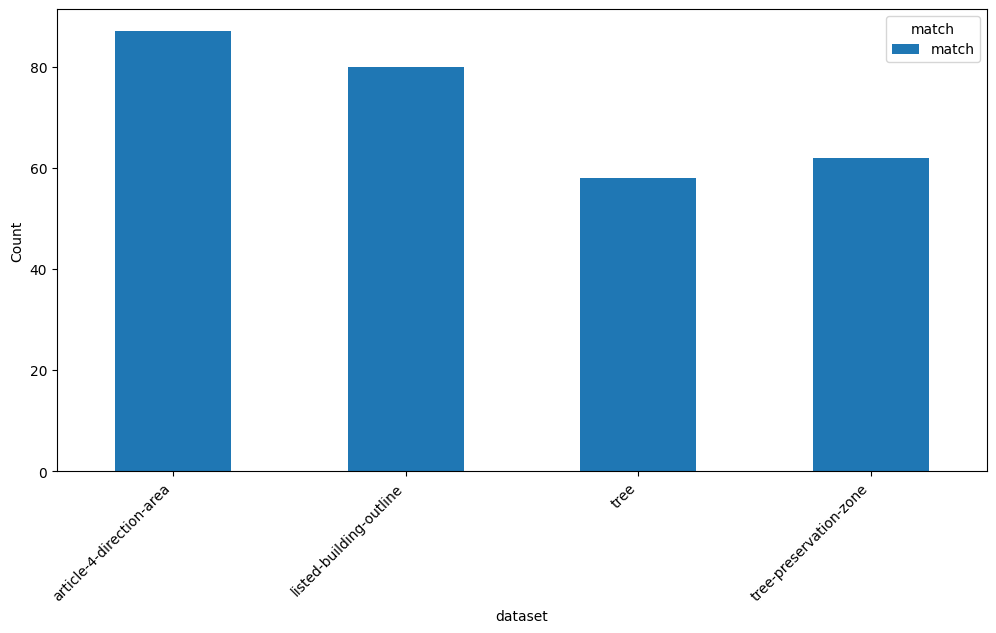

In [122]:
f, ax = plt.subplots(figsize=(12, 6))

data = lpa_summary.groupby(['dataset', 'match']).size().unstack(fill_value=0)

data.plot(kind='bar', ax=ax)
plt.xticks(rotation=45, ha='right')

ax.set_ylabel('Count')

plt.show()